# Electric Vehicle Purchases Prediction

Predicting probability - `Will_Buy_EV` variable

## Imports and loading dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)


train_df = pd.read_csv('/Users/gabrielaslomiany/PyCharmMiscProject/Small-ML/Electric Vehicle Purchases/data/train.csv')
test_df = pd.read_csv('/Users/gabrielaslomiany/PyCharmMiscProject/Small-ML/Electric Vehicle Purchases/data/test.csv')

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
train_df.head()

train shape: (668665, 15)
test shape: (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## Checking training set

In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [3]:
train_df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [4]:
train_df.isna().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

## Preprocessing

;))

In [5]:
str_cols = train_df.select_dtypes(include='str').columns
print(str_cols.tolist())

['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']


Checking unique values for each of the str columns

In [6]:
for col in str_cols:
    print(col, train_df[col].unique())

Gender <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
City_Type <StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str
Current_Car_Type <StringArray>
['Sedan', 'SUV', 'Hatchback', 'Truck']
Length: 4, dtype: str
Home_Charging_Possible <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Subsidy_Available <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Range_Anxiety_Level <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Will_Buy_EV <StringArray>
['No', 'Yes']
Length: 2, dtype: str


## Full preprocessing pipeline (numeric scaling + categorical encoding)

- **Binary** (`Home_Charging_Possible`, `Subsidy_Available`): Yes/No → one-hot encoded, dropping one level since they're binary.
- **Nominal** (`Gender`, `City_Type`, `Current_Car_Type`): no inherent order → one-hot encoded.
- **Ordinal** (`Range_Anxiety_Level`): Low < Medium < High → ordinal encoded preserving rank.

In [7]:
numeric_features = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
                     'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
                     'Environmental_Concern_Level']
binary_features = ['Home_Charging_Possible', 'Subsidy_Available']
nominal_features = ['Gender', 'City_Type', 'Current_Car_Type']
ordinal_features = ['Range_Anxiety_Level']
ordinal_categories = [['Low', 'Medium', 'High']]

numeric_pipeline = Pipeline([('scaler', StandardScaler())])
binary_pipeline = Pipeline([('encoder', OneHotEncoder(drop='if_binary'))])
nominal_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))])
ordinal_pipeline = Pipeline([('encoder', OrdinalEncoder(categories=ordinal_categories))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nom', nominal_pipeline, nominal_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('bin', binary_pipeline, binary_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [8]:
X = train_df.drop(columns=['id', 'Will_Buy_EV'])
y = (train_df['Will_Buy_EV'] == 'Yes').astype(int)

train_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

train_encoded_df = pd.DataFrame(train_encoded, columns=feature_names, index=X.index)
train_encoded_df

,num__Age,num__Annual_Income_USD,num__Daily_Commute_km,num__Number_of_Cars_Owned,num__Charging_Stations_Near_Home,num__Charging_Stations_Near_Work,num__Environmental_Concern_Level,nom__Gender_Female,nom__Gender_Male,nom__Gender_Other,nom__City_Type_Rural,nom__City_Type_Suburban,nom__City_Type_Urban,nom__Current_Car_Type_Hatchback,nom__Current_Car_Type_SUV,nom__Current_Car_Type_Sedan,nom__Current_Car_Type_Truck,ord__Range_Anxiety_Level,bin__Home_Charging_Possible_Yes,bin__Subsidy_Available_Yes
0,1.472636,0.283361,-0.467597,0.394055,-0.499233,-0.033994,-1.354316,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.702048,-1.911800,-1.449954,-0.977170,-0.753891,-0.998012,0.744881,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.634055,0.335791,0.247816,-0.977170,0.774056,1.508436,1.444613,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.472636,-0.390577,-0.451580,0.394055,0.264740,0.351613,0.045149,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.540629,-0.937980,0.995261,-0.977170,-0.753891,-0.805209,0.045149,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,-1.323386,-0.477495,-0.254041,0.394055,0.010082,-0.226798,1.444613,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
668661,-1.168051,1.578495,-1.449954,0.394055,0.010082,-0.612405,-1.354316,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
668662,1.317301,1.292297,-0.424885,-0.977170,0.010082,-0.226798,-1.354316,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
668663,0.307627,1.087466,0.616200,0.394055,-1.263206,-1.383620,-1.354316,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [9]:
train_encoded_df.dtypes

num__Age                            float64
num__Annual_Income_USD              float64
num__Daily_Commute_km               float64
num__Number_of_Cars_Owned           float64
num__Charging_Stations_Near_Home    float64
num__Charging_Stations_Near_Work    float64
num__Environmental_Concern_Level    float64
nom__Gender_Female                  float64
nom__Gender_Male                    float64
nom__Gender_Other                   float64
nom__City_Type_Rural                float64
nom__City_Type_Suburban             float64
nom__City_Type_Urban                float64
nom__Current_Car_Type_Hatchback     float64
nom__Current_Car_Type_SUV           float64
nom__Current_Car_Type_Sedan         float64
nom__Current_Car_Type_Truck         float64
ord__Range_Anxiety_Level            float64
bin__Home_Charging_Possible_Yes     float64
bin__Subsidy_Available_Yes          float64
dtype: object

## Train test & models

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
results = {}
fitted_pipelines = {}

def evaluate(name, pipeline):
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, val_pred)
    results[name] = auc
    fitted_pipelines[name] = pipeline
    print(f'{name:12s} validation ROC-AUC: {auc:.4f}')
    return pipeline

### Logistic Regression

In [12]:
logreg_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
evaluate('LogReg', logreg_pipe)

LogReg       validation ROC-AUC: 0.9380


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

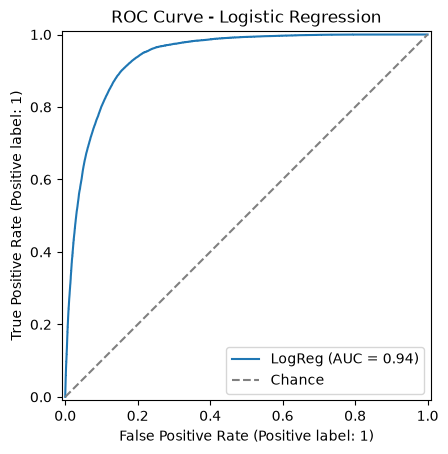

In [13]:
RocCurveDisplay.from_estimator(logreg_pipe, X_val, y_val, name='LogReg')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [14]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)),
])
evaluate('RF', rf_pipe)

RF           validation ROC-AUC: 0.9345


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

In [15]:
xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=400, tree_method='hist', eval_metric='auc',
        random_state=42,
    )),
])
evaluate('XGB', xgb_pipe)

XGB          validation ROC-AUC: 0.9384


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

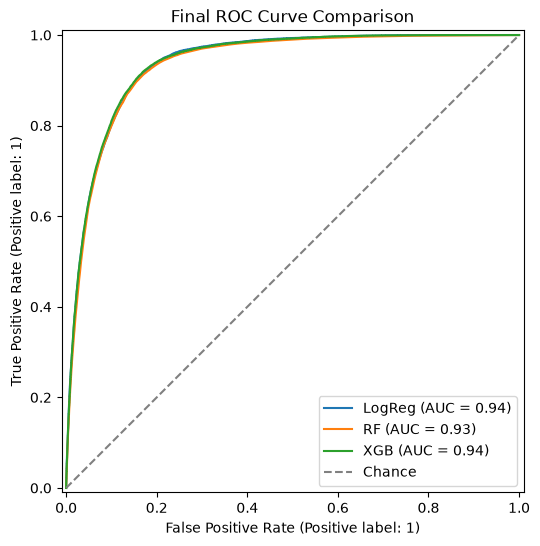

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_val, y_val, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('Final ROC Curve Comparison')
ax.legend()
plt.show()

        val_roc_auc
XGB        0.938404
LogReg     0.937968
RF         0.934532


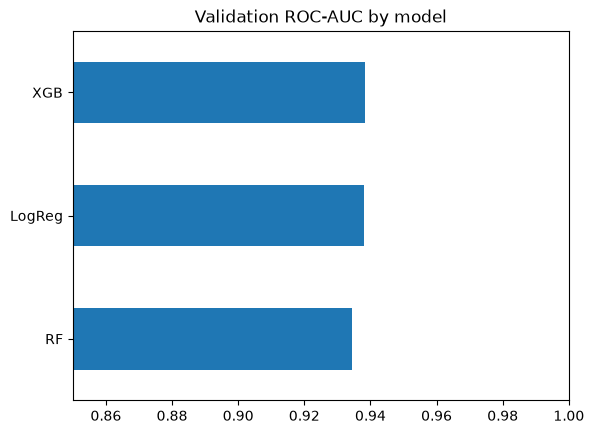

In [17]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['val_roc_auc']).sort_values('val_roc_auc', ascending=False)
print(results_df)

results_df['val_roc_auc'].plot(kind='barh', title='Validation ROC-AUC by model')
plt.gca().invert_yaxis()
plt.xlim(0.85, 1.0)
plt.show()

## Model tuning

In [25]:
xgb_search_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(tree_method='hist', eval_metric='auc', random_state=42)),
])

param_dist = {
    'clf__n_estimators': [200, 300, 400, 500],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.02, 0.03, 0.05, 0.1],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_search_pipe, param_dist, n_iter=10, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=1, verbose=1,
)
search.fit(X_train, y_train)

print('Best CV ROC-AUC:', search.best_score_)
print('Best params:', search.best_params_)

xgb_tuned = search.best_estimator_
val_auc = roc_auc_score(y_val, xgb_tuned.predict_proba(X_val)[:, 1])
print('Tuned XGB validation ROC-AUC:', val_auc)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV ROC-AUC: 0.9415509984435739
Best params: {'clf__subsample': 1.0, 'clf__n_estimators': 600, 'clf__max_depth': 5, 'clf__learning_rate': 0.07, 'clf__colsample_bytree': 1.0}
Tuned XGB validation ROC-AUC: 0.9416445703767705


In [19]:
results['XGB_tuned'] = val_auc
fitted_pipelines['XGB_tuned'] = xgb_tuned
print(f'XGB_tuned    validation ROC-AUC: {val_auc:.4f}')

XGB_tuned    validation ROC-AUC: 0.9417


In [26]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['val_roc_auc']).sort_values('val_roc_auc', ascending=False)
print(results_df)

           val_roc_auc
XGB_tuned     0.941733
XGB           0.938404
LogReg        0.937968
RF            0.934532


## Final predictions on test set

Refit the best-scoring model (by validation ROC-AUC) on all of `train_df`, then predict `Will_Buy_EV` probabilities for `test_df`.

In [28]:
best_model_name = results_df.index[0]
print(f'Best model: {best_model_name} (val ROC-AUC = {results_df.loc[best_model_name, "val_roc_auc"]:.4f})')

best_pipeline = fitted_pipelines[best_model_name]
best_pipeline.fit(X, y)

test_features = test_df.drop(columns=['id'])
test_pred_proba = best_pipeline.predict_proba(test_features)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'Will_Buy_EV': test_pred_proba
})
submission.to_csv('submission.csv', index=False)
submission.head()

Best model: XGB_tuned (val ROC-AUC = 0.9417)


,id,Will_Buy_EV
0,668665,0.010318
1,668666,0.020050
2,668667,0.005316
3,668668,0.002915
4,668669,0.024194
